# Telco Customer Churn Analysis & Feature Engineering

Bu çalışmada Telco Customer Churn veri seti üzerinde keşifçi veri analizi,
veri ön işleme, feature engineering ve modelleme adımları gerçekleştirilecektir.

In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from catboost import CatBoostClassifier

## 1. Data Loading

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. General Overview

Veri setinin boyutu, değişken isimleri ve veri tipleri incelenmektedir.

In [3]:
print(df.shape)
print(df.columns)

df.info()

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non

### Initial Observation

`TotalCharges` değişkeni toplam ücret bilgisini temsil etmesine rağmen
`object` veri tipinde görünmektedir. Bunun nedeni araştırılacaktır.

In [4]:
df["TotalCharges"].unique()[:30]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9', '39.65', '202.25', '20.15', '3505.1', '2970.3',
       '1530.6', '4749.15', '30.2', '6369.45', '1093.1'], dtype=object)

In [5]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

TotalCharges değişkeninde yalnızca boşluk karakterinden oluşan 11 gözlem bulunmaktadır. Bu gözlemlerin ortak özellikleri incelenecektir.

In [6]:
problem_rows = df[df["TotalCharges"] == " "]

problem_rows[
    ["tenure", "MonthlyCharges", "Contract", "PaymentMethod", "Churn"]
]

,tenure,MonthlyCharges,Contract,PaymentMethod,Churn
488,0,52.55,Two year,Bank transfer (automatic),No
753,0,20.25,Two year,Mailed check,No
936,0,80.85,Two year,Mailed check,No
1082,0,25.75,Two year,Mailed check,No
1340,0,56.05,Two year,Credit card (automatic),No
3331,0,19.85,Two year,Mailed check,No
3826,0,25.35,Two year,Mailed check,No
4380,0,20.00,Two year,Mailed check,No
5218,0,19.70,One year,Mailed check,No
6670,0,73.35,Two year,Mailed check,No


Boş `TotalCharges` değerine sahip 11 müşterinin tamamında `tenure = 0`
olduğu gözlemlenmiştir.

Bu durum, müşterilerin henüz şirkette bir ayını tamamlamamış olması nedeniyle
toplam ücret bilgisinin oluşmamış olabileceğini düşündürmektedir.

In [7]:
df[df["tenure"] == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
((df["tenure"] == 0) & (df["TotalCharges"] != " ")).sum()

np.int64(0)


### TotalCharges Data Type Correction

Boş `TotalCharges` değerlerinin tamamının `tenure = 0` olan müşterilere ait olduğu ve `tenure = 0` olup dolu bir `TotalCharges` değerine sahip müşteri bulunmadığı doğrulanmıştır.

Bu nedenle söz konusu değerler 0 olarak atanmış ve `TotalCharges` değişkeni numerik analizlerde kullanılabilmesi için `float` veri tipine dönüştürülmüştür.

In [9]:
df.loc[df["TotalCharges"] == " ", "TotalCharges"] = 0

df["TotalCharges"] = df["TotalCharges"].astype(float)

In [10]:
print(df["TotalCharges"].dtype)
print((df["TotalCharges"] == " ").sum())

float64
0


## 3. Variable Types

Veri setindeki kategorik, numerik ve kategorik görünümlü kardinal
değişkenler belirlenmektedir.

In [11]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """

    Veri setindeki kategorik, numerik ve kategorik fakat kardinal değişkenlerin isimlerini verir.
    Not: Kategorik değişkenlerin içerisine numerik görünümlü kategorik değişkenler de dahildir.

    Parameters
    ------
        dataframe: dataframe
                Değişken isimleri alınmak istenilen dataframe
        cat_th: int, optional
                numerik fakat kategorik olan değişkenler için sınıf eşik değeri
        car_th: int, optional
                kategorik fakat kardinal değişkenler için sınıf eşik değeri

    Returns
    ------
        cat_cols: list
                Kategorik değişken listesi
        num_cols: list
                Numerik değişken listesi
        cat_but_car: list
                Kategorik görünümlü kardinal değişken listesi

    Notes
    ------
        cat_cols + num_cols + cat_but_car = toplam değişken sayısı
        num_but_cat cat_cols'un içerisinde.
    """

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]

    num_but_cat = [
        col for col in dataframe.columns
        if dataframe[col].nunique() < cat_th
        and dataframe[col].dtypes != "O"
    ]

    cat_but_car = [
        col for col in dataframe.columns
        if dataframe[col].nunique() > car_th
        and dataframe[col].dtypes == "O"
    ]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [
        col for col in dataframe.columns
        if dataframe[col].dtypes != "O"
    ]

    num_cols = [
        col for col in num_cols
        if col not in num_but_cat
    ]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")

    return cat_cols, num_cols, cat_but_car

In [12]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 7043
Variables: 21
cat_cols: 17
num_cols: 3
cat_but_car: 1
num_but_cat: 1


In [13]:
print("cat_cols:", cat_cols)
print("num_cols:", num_cols)
print("cat_but_car:", cat_but_car)

cat_cols: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'SeniorCitizen']
num_cols: ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_but_car: ['customerID']


### Variable Type Observations

- `SeniorCitizen` numerik olarak tutulmasına rağmen 0/1 sınıflarını temsil ettiği için kategorik değişken olarak değerlendirilmiştir.
- `customerID` çok sayıda benzersiz değere sahip olduğu için `cat_but_car` olarak yakalanmıştır ancak değişken aslında müşteri kimliğidir.
- `tenure`, `MonthlyCharges` ve düzeltilen `TotalCharges` numerik değişkenlerdir.

## 4. Categorical and Numerical Variable Analysis

Bu bölümde kategorik değişkenlerin sınıf frekansları ve veri setindeki oranları ile numerik değişkenlerin dağılımları ve temel istatistiksel özellikleri incelenmektedir.

In [14]:
cat_summary_df = pd.concat([
    pd.DataFrame({
        "Variable": col,
        "Category": df[col].value_counts().index,
        "Count": df[col].value_counts().values,
        "Ratio (%)": (100 * df[col].value_counts().values / len(df)).round(2)
    })
    for col in cat_cols
], ignore_index=True)

pd.set_option("display.max_rows", None)
display(cat_summary_df)

,Variable,Category,Count,Ratio (%)
0,gender,Male,3555,50.48
1,gender,Female,3488,49.52
2,Partner,No,3641,51.70
3,Partner,Yes,3402,48.30
4,Dependents,No,4933,70.04
5,Dependents,Yes,2110,29.96
6,PhoneService,Yes,6361,90.32
7,PhoneService,No,682,9.68
8,MultipleLines,No,3390,48.13
9,MultipleLines,Yes,2971,42.18


### Categorical Variable Observations

- Cinsiyet dağılımı oldukça dengelidir; müşterilerin %50.48'i erkek, %49.52'si kadındır.
- Müşterilerin %55.02'si `Month-to-month` sözleşmeye sahiptir. Bu grup sözleşme türleri içinde en büyük gruptur.
- İnternet hizmeti türlerinde en büyük grup %43.96 ile `Fiber optic` müşterileridir.
- En sık kullanılan ödeme yöntemi %33.58 ile `Electronic check` yöntemidir.
- Müşterilerin %59.22'si kağıtsız faturalandırma kullanmaktadır.
- Müşterilerin %83.79'u senior citizen değildir.
- Hedef değişkende müşterilerin %73.46'sı churn etmemiş, %26.54'ü churn etmiştir. Bu dağılım hedef değişkende sınıf dengesizliği bulunduğunu göstermektedir.

In [15]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40,
                 0.50, 0.60, 0.70, 0.80, 0.90,
                 0.95, 0.99]

    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
5%          1.000000
10%         2.000000
20%         6.000000
30%        12.000000
40%        20.000000
50%        29.000000
60%        40.000000
70%        50.000000
80%        60.000000
90%        69.000000
95%        72.000000
99%        72.000000
max        72.000000
Name: tenure, dtype: float64


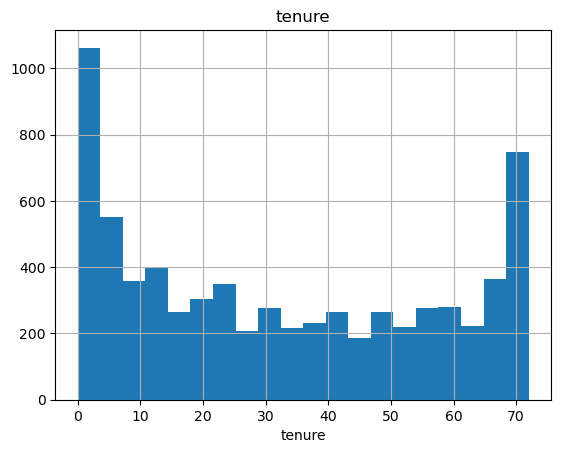

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
5%         19.650000
10%        20.050000
20%        25.050000
30%        45.850000
40%        58.830000
50%        70.350000
60%        79.100000
70%        85.500000
80%        94.250000
90%       102.600000
95%       107.400000
99%       114.729000
max       118.750000
Name: MonthlyCharges, dtype: float64


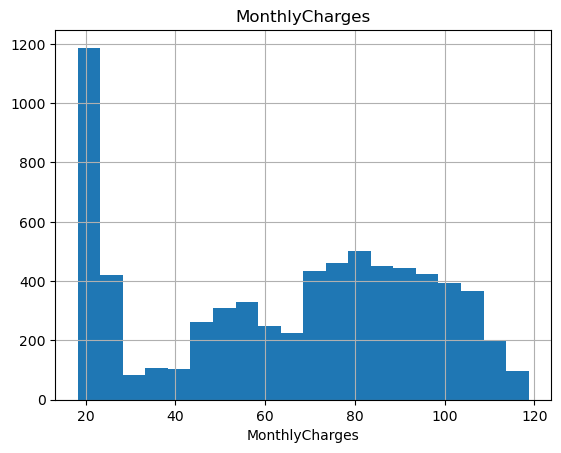

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
5%         48.600000
10%        83.470000
20%       265.320000
30%       548.400000
40%       939.780000
50%      1394.550000
60%      2043.710000
70%      3132.750000
80%      4471.440000
90%      5973.690000
95%      6921.025000
99%      8039.256000
max      8684.800000
Name: TotalCharges, dtype: float64


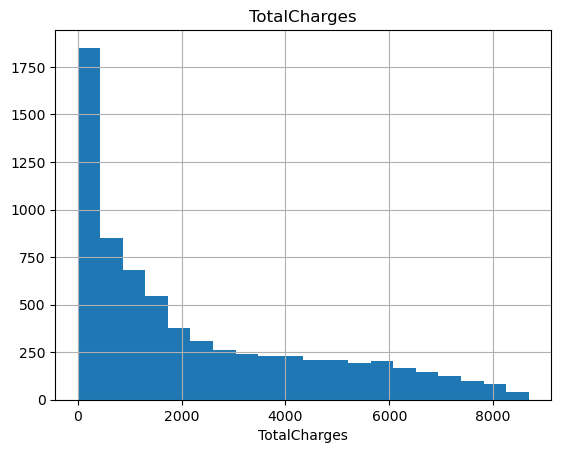

In [16]:
for col in num_cols:
    num_summary(df, col, plot=True)

### Numerical Variable Observations

- Müşterilerin şirkette kalma süresi (`tenure`) 0–72 ay arasında değişmekte, ortalama 32.37 ay ve medyan 29 aydır.
- `MonthlyCharges` 18.25 ile 118.75 arasında değişmektedir. Ortalama aylık ücret 64.76, medyan ise 70.35'tir.
- `TotalCharges` 0 ile 8684.80 arasında değişmektedir. Ortalama toplam ücret 2279.73, medyan ise 1394.55'tir.
- `TotalCharges` değişkeninde ortalamanın medyandan belirgin şekilde yüksek olması, dağılımın yüksek değerlere doğru uzadığını göstermektedir.

## 5. Target Analysis

In [17]:

df["Churn_num"] = df["Churn"].map({"No": 0, "Yes": 1})

In [18]:
df[["Churn", "Churn_num"]].head()

,Churn,Churn_num
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [19]:
df.groupby("Contract")["Churn_num"].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn_num, dtype: float64

In [20]:
df.groupby("gender")["Churn_num"].mean()

gender
Female    0.269209
Male      0.261603
Name: Churn_num, dtype: float64

In [21]:
def target_summary_with_cat(dataframe, target, categorical_col):
    print(pd.DataFrame({
        "TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean()
    }), end="\n\n\n")

In [22]:
for col in cat_cols:
    if col != "Churn":
        target_summary_with_cat(df, "Churn_num", col)

        TARGET_MEAN
gender             
Female     0.269209
Male       0.261603


         TARGET_MEAN
Partner             
No          0.329580
Yes         0.196649


            TARGET_MEAN
Dependents             
No             0.312791
Yes            0.154502


              TARGET_MEAN
PhoneService             
No               0.249267
Yes              0.267096


                  TARGET_MEAN
MultipleLines                
No                   0.250442
No phone service     0.249267
Yes                  0.286099


                 TARGET_MEAN
InternetService             
DSL                 0.189591
Fiber optic         0.418928
No                  0.074050


                     TARGET_MEAN
OnlineSecurity                  
No                      0.417667
No internet service     0.074050
Yes                     0.146112


                     TARGET_MEAN
OnlineBackup                    
No                      0.399288
No internet service     0.074050
Yes                     0.2153

In [23]:
results = []

for col in cat_cols:
    if col != "Churn":
        temp = df.groupby(col, as_index=False)["Churn_num"].mean()

        temp = temp.rename(columns={
            col: "Category",
            "Churn_num": "Churn_Rate"
        })

        temp.insert(0, "Variable", col)

        results.append(temp)

cat_target_summary = pd.concat(results, ignore_index=True)

cat_target_summary

,Variable,Category,Churn_Rate
0,gender,Female,0.269209
1,gender,Male,0.261603
2,Partner,No,0.329580
3,Partner,Yes,0.196649
4,Dependents,No,0.312791
5,Dependents,Yes,0.154502
6,PhoneService,No,0.249267
7,PhoneService,Yes,0.267096
8,MultipleLines,No,0.250442
9,MultipleLines,No phone service,0.249267


### Kategorik Değişkenlerin Churn ile İlişkisi

Kategorik değişkenler incelendiğinde churn oranlarının bazı gruplarda belirgin şekilde farklılaştığı görülmektedir.

- Month-to-month sözleşmeye sahip müşterilerde churn oranı yaklaşık %42.7 iken, iki yıllık sözleşmeye sahip müşterilerde bu oran %2.8'dir.
- Electronic check kullanan müşterilerin churn oranı yaklaşık %45.3 ile diğer ödeme yöntemlerinden daha yüksektir.
- Fiber optic internet kullanan müşterilerde churn oranı yaklaşık %41.9'dur.
- OnlineSecurity ve TechSupport hizmeti olmayan müşterilerde churn oranı daha yüksektir.
- SeniorCitizen müşterilerde churn oranı yaklaşık %41.7 iken diğer müşterilerde %23.6'dır.
- Gender ve PhoneService değişkenlerinde gruplar arasındaki churn oranları oldukça yakın olduğundan belirgin bir farklılık gözlenmemektedir.

Bu sonuçlar özellikle Contract, PaymentMethod, InternetService, OnlineSecurity, TechSupport ve SeniorCitizen değişkenlerinin churn açısından dikkat çekici olabileceğini göstermektedir.

In [24]:
num_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [25]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [26]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [27]:
df.groupby("Churn")["TotalCharges"].mean()

Churn
No     2549.911442
Yes    1531.796094
Name: TotalCharges, dtype: float64

In [28]:
def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")

In [29]:
for col in num_cols:
    target_summary_with_num(df, "Churn", col)

          tenure
Churn           
No     37.569965
Yes    17.979133


       MonthlyCharges
Churn                
No          61.265124
Yes         74.441332


       TotalCharges
Churn              
No      2549.911442
Yes     1531.796094




### Numerik Değişkenlerin Churn ile İlişkisi

Churn olan müşterilerin ortalama tenure süresi yaklaşık 18 ay iken churn olmayan müşterilerde bu süre yaklaşık 38 aydır; bu durum ayrılan müşterilerin şirkette daha kısa süre kaldığını göstermektedir. Aylık ücretler incelendiğinde churn olan müşterilerin ortalama MonthlyCharges değeri yaklaşık 74.4, churn olmayan müşterilerin ise 61.3 olup, ayrılan müşterilerin aylık ödemelerinin daha yüksek olduğu görülmektedir. TotalCharges değerinde ise churn olmayan müşterilerin ortalaması yaklaşık 2549.9, churn olan müşterilerin ortalaması yaklaşık 1531.8’dir. Ancak TotalCharges müşterinin şirkette kaldığı süreyle doğrudan ilişkili olduğundan, churn olmayan müşterilerin daha uzun tenure süresine sahip olması toplam ödemelerinin de daha yüksek çıkmasını açıklayabilir. Bu nedenle numerik değişkenler birlikte değerlendirildiğinde, churn olan müşterilerin daha kısa süre şirkette kaldığı, aylık olarak daha yüksek ücret ödediği ancak daha kısa süre kaldıkları için toplam ödemelerinin daha düşük olduğu görülmektedir.

## 6. Outlier Analysis
Numerik değişkenlerde olası aykırı değerler IQR yöntemi kullanılarak incelenecektir.

In [30]:
def outlier_thresholds(dataframe, col_name, q1=0.25, q3=0.75):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

In [31]:
outlier_thresholds(df, "tenure")

(np.float64(-60.0), np.float64(124.0))

In [32]:
def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)

    return ((dataframe[col_name] > up_limit) |
            (dataframe[col_name] < low_limit)).any()

In [33]:
for col in num_cols:
    print(col, check_outlier(df, col))

tenure False
MonthlyCharges False
TotalCharges False


### Aykırı Değer Analizi Sonucu

Numerik değişkenler IQR yöntemi ile incelenmiştir. `tenure`, `MonthlyCharges` ve `TotalCharges` değişkenlerinde belirlenen alt ve üst sınırların dışında kalan herhangi bir aykırı değer tespit edilmemiştir.

## 7. Missing Value Analysis

In [34]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Churn_num           0
dtype: int64

In [35]:
(df[num_cols] == 0).sum()

tenure            11
MonthlyCharges     0
TotalCharges      11
dtype: int64

In [36]:
((df["TotalCharges"] == 0) & (df["tenure"] != 0)).sum()

np.int64(0)

### Eksik Değer Analizi Sonucu

Veri setinde `NaN` tipinde eksik değer bulunmamaktadır. Ayrıca numerik değişkenlerde 0 değerleri kontrol edilmiştir. `tenure` ve `TotalCharges` değişkenlerinde 11'er adet 0 değer bulunduğu ve bu değerlerin aynı müşterilere ait olduğu doğrulanmıştır. Bu müşterilerin `tenure = 0` olması nedeniyle `TotalCharges = 0` değerleri anlamlı kabul edilmiştir. `MonthlyCharges` değişkeninde ise 0 değer bulunmamaktadır.

## 8. Correlation Analysis

In [37]:
df[num_cols].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


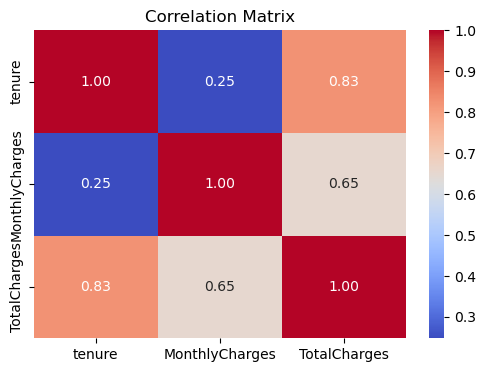

In [38]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Korelasyon Analizi Sonucu

Numerik değişkenler arasındaki korelasyonlar incelendiğinde, `tenure` ile `TotalCharges` arasında güçlü pozitif bir ilişki (0.83) olduğu görülmektedir. Bu durum, müşterilerin şirkette kaldıkları süre arttıkça toplam ödemelerinin de artmasıyla açıklanabilir. `MonthlyCharges` ile `TotalCharges` arasında da orta-güçlü pozitif bir ilişki (0.65) bulunmaktadır. Buna karşılık `tenure` ile `MonthlyCharges` arasındaki ilişki daha zayıftır (0.25).

## 9. Baseline Models - Before Feature Engineering

Feature engineering işlemlerinin model performansına katkısını değerlendirebilmek amacıyla, yeni değişkenler oluşturulmadan önce orijinal değişkenler kullanılarak beş farklı sınıflandırma modeli kurulmuştur: Logistic Regression, Random Forest, Gradient Boosting, CatBoost ve class-weight dengeli Logistic Regression.

Elde edilen sonuçlar, aynı modellerin feature engineering sonrasındaki performanslarıyla karşılaştırılacaktır.

In [39]:
base_df = pd.read_csv("Telco-Customer-Churn.csv")

In [40]:
base_df.loc[base_df["TotalCharges"] == " ", "TotalCharges"] = 0
base_df["TotalCharges"] = base_df["TotalCharges"].astype(float)

base_df["Churn_num"] = base_df["Churn"].map({"No": 0, "Yes": 1})

In [41]:
X_base = base_df.drop(columns=["customerID", "Churn", "Churn_num"])
y_base = base_df["Churn_num"]

In [42]:
X_base = pd.get_dummies(X_base, drop_first=True, dtype=int)

In [43]:
X_base_train, X_base_test, y_base_train, y_base_test = train_test_split(
    X_base,
    y_base,
    test_size=0.20,
    random_state=42,
    stratify=y_base
)

In [44]:
base_scale_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

base_scaler = StandardScaler()

X_base_train[base_scale_cols] = base_scaler.fit_transform(
    X_base_train[base_scale_cols]
)

X_base_test[base_scale_cols] = base_scaler.transform(
    X_base_test[base_scale_cols]
)

In [45]:
base_log_model = LogisticRegression(max_iter=1000)

base_log_model.fit(X_base_train, y_base_train)

base_pred = base_log_model.predict(X_base_test)

print(classification_report(y_base_test, base_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [46]:
base_rf_model = RandomForestClassifier(
    random_state=42
)

base_rf_model.fit(X_base_train, y_base_train)

base_rf_pred = base_rf_model.predict(X_base_test)

print(classification_report(y_base_test, base_rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



In [47]:
base_gb_model = GradientBoostingClassifier(
    random_state=42
)

base_gb_model.fit(X_base_train, y_base_train)

base_gb_pred = base_gb_model.predict(X_base_test)

print(classification_report(y_base_test, base_gb_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [48]:
base_cat_model = CatBoostClassifier(
    verbose=False,
    random_state=42
)

base_cat_model.fit(X_base_train, y_base_train)

base_cat_pred = base_cat_model.predict(X_base_test)

print(classification_report(y_base_test, base_cat_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [49]:

base_balanced_log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

base_balanced_log_model.fit(X_base_train, y_base_train)

base_balanced_pred = base_balanced_log_model.predict(X_base_test)

print(classification_report(y_base_test, base_balanced_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### Baseline Model Results

Feature engineering öncesinde kurulan modeller karşılaştırıldığında, standart Logistic Regression %81 ile en yüksek doğruluk oranını elde etmiştir. CatBoost ve Gradient Boosting modelleri ise yaklaşık %80 doğruluk göstermiştir.

Churn sınıfını yakalama başarısı açısından sonuçlar farklılaşmaktadır. Standart modellerde churn recall değeri %49–56 aralığında kalırken, sınıf ağırlıkları dengelenmiş Logistic Regression modelinde recall %78'e yükselmiştir. Bununla birlikte bu modelin precision değeri %50'ye ve genel accuracy değeri %74'e düşmüştür.

Bu nedenle baseline sonuçları, genel doğruluk ile churn müşterilerini daha yüksek oranda tespit etme hedefi arasında bir performans dengesi bulunduğunu göstermektedir.

## 10. Feature Engineering

### Yeni Değişkenlerin Oluşturulması

Keşifsel veri analizi sonucunda bazı kategorik değişkenlerin churn oranları açısından belirgin farklılıklar gösterdiği görülmüştür. Özellikle `Contract`, `PaymentMethod`, `InternetService`, `OnlineSecurity`, `TechSupport` ve `SeniorCitizen` değişkenleri dikkat çekmiştir.

Bu bölümde, mevcut değişkenlerden churn davranışını daha iyi açıklayabilecek yeni değişkenler oluşturulacaktır. Yeni değişkenler oluşturulmadan önce, EDA bulgularına dayanarak bazı değişken kombinasyonlarının churn ile ilişkisi incelenecektir.

Özellikle aşağıdaki ilişkiler değerlendirilecektir:

- `Contract` ve `PaymentMethod`
- `InternetService` ve `TechSupport`
- `InternetService` ve `OnlineSecurity`
- `tenure` değerinin müşteri süresine göre gruplandırılması
- Müşterinin kullandığı ek hizmet sayısını temsil eden değişkenler

Bu analizler sonucunda anlamlı görülen kombinasyonlar yeni özellikler olarak veri setine eklenecektir.

In [50]:
df[
    (df["Contract"] == "Month-to-month") &
    (df["PaymentMethod"] == "Electronic check")
]["Churn_num"].mean()

np.float64(0.5372972972972972)

In [51]:
df[
    (df["Contract"] == "Month-to-month") &
    (df["PaymentMethod"] == "Electronic check")
].shape[0]

1850

In [52]:
df[
    (df["InternetService"] == "Fiber optic") &
    (df["TechSupport"] == "No")
]["Churn_num"].mean()

np.float64(0.49372197309417043)

In [53]:
df[
    (df["InternetService"] == "Fiber optic") &
    (df["TechSupport"] == "No")
].shape[0]

2230

In [54]:
df[
    (df["InternetService"] == "Fiber optic") &
    (df["OnlineSecurity"] == "No")
]["Churn_num"].mean()

np.float64(0.4935755427558706)

In [55]:
df[
    (df["InternetService"] == "Fiber optic") &
    (df["OnlineSecurity"] == "No")
].shape[0]

2257

In [56]:
df["NEW_Monthly_Echeck"] = (
    (df["Contract"] == "Month-to-month") &
    (df["PaymentMethod"] == "Electronic check")
).astype(int)

df["NEW_Fiber_NoSupport"] = (
    (df["InternetService"] == "Fiber optic") &
    (df["TechSupport"] == "No")
).astype(int)

In [57]:
df[["NEW_Monthly_Echeck", "NEW_Fiber_NoSupport"]].head()

,NEW_Monthly_Echeck,NEW_Fiber_NoSupport
0,1,0
1,0,0
2,0,0
3,0,0
4,1,1


### Etkileşim Değişkenlerinin Değerlendirilmesi

EDA bulgularına dayanarak bazı değişken kombinasyonlarının churn oranları ayrıca incelenmiştir. `Month-to-month` sözleşme ile `Electronic check` ödeme yönteminin birlikte bulunduğu müşteri grubunda churn oranı yaklaşık %53.7 olarak gözlenmiştir. Bu nedenle bu kombinasyon yeni bir etkileşim değişkeni olarak kullanılacaktır.
Ayrıca `Fiber optic + TechSupport = No` ve `Fiber optic + OnlineSecurity = No` kombinasyonlarının churn oranları incelenmiş ve her iki grubun da yaklaşık %49 churn oranına sahip olduğu görülmüştür. Bu iki kombinasyon benzer churn oranları gösterdiği ve oluşturulan değişken sayısını gereksiz şekilde artırmamak amacıyla yalnızca `Fiber optic + TechSupport = No` kombinasyonu yeni değişken olarak kullanılmıştır.


### Tenure Gruplarının Değerlendirilmesi

In [58]:
tenure_group = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

df.groupby(tenure_group, observed=True)["Churn_num"].mean()

tenure
0-12     0.474382
13-24    0.287109
25-48    0.203890
49-72    0.095132
Name: Churn_num, dtype: float64

In [59]:
df["NEW_TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

In [60]:
df[["tenure", "NEW_TenureGroup"]].head()

,tenure,NEW_TenureGroup
0,1,0-12
1,34,25-48
2,2,0-12
3,45,25-48
4,2,0-12


`tenure` değerleri gruplandırıldığında churn oranının müşteri süresi arttıkça belirgin biçimde azaldığı görülmüştür. İlk 12 ay içindeki müşterilerde churn oranı yaklaşık %47.4 iken, 49–72 ay aralığındaki müşterilerde bu oran yaklaşık %9.5'e düşmektedir. Bu nedenle müşteri süresini kategorik olarak temsil eden `NEW_TenureGroup` değişkeni oluşturulmuştur.

### İnternet Ek Hizmet Sayısının Değerlendirilmesi

In [61]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

total_services = (df[service_cols] == "Yes").sum(axis=1)

df.groupby(total_services)["Churn_num"].agg(["mean", "count"])

,mean,count
0,0.214060,2219
1,0.457557,966
2,0.358180,1033
3,0.273703,1118
4,0.223005,852
5,0.124343,571
6,0.052817,284


In [62]:
df.assign(TotalServices=total_services).groupby(
    ["TotalServices", "InternetService"]
)["Churn_num"].agg(["mean", "count"])

mean  count
TotalServices InternetService                 
0             DSL              0.411565    294
              Fiber optic      0.604010    399
              No               0.074050   1526
1             DSL              0.322892    415
              Fiber optic      0.558984    551
2             DSL              0.202643    454
              Fiber optic      0.480138    579
3             DSL              0.130526    475
              Fiber optic      0.379471    643
4             DSL              0.091922    359
              Fiber optic      0.318458    493
5             DSL              0.053381    281
              Fiber optic      0.193103    290
6             DSL              0.013986    143
              Fiber optic      0.092199    141

In [63]:
df["NEW_InternetAddonCount"] = (df[service_cols] == "Yes").sum(axis=1)

`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV` ve `StreamingMovies` hizmetleri kullanılarak müşterilerin sahip olduğu internet ek hizmet sayısı hesaplanmıştır. İlk analizde ek hizmeti olmayan müşterilerin churn oranının beklenenden düşük olduğu görülmüştür. Bu grup ayrıca incelendiğinde, internet hizmeti bulunmayan müşterilerin churn oranının yaklaşık %7.4 olduğu ve 0 hizmet grubunun genel churn oranını düşürdüğü görülmüştür. Buna karşılık internet hizmeti bulunan ve ek hizmet kullanmayan müşterilerde churn oranı daha yüksektir. Bu nedenle müşterinin kullandığı ek internet hizmetlerinin sayısını temsil eden `NEW_InternetAddonCount` değişkeni oluşturulmuştur.

### Partner ve Dependents Etkileşiminin Değerlendirilmesi

In [64]:
df.groupby(["Partner", "Dependents"])["Churn_num"].agg(["mean", "count"])

mean  count
Partner Dependents                 
No      No          0.342378   3280
        Yes         0.213296    361
Yes     No          0.254083   1653
        Yes         0.142367   1749



`Partner` ve `Dependents` değişkenlerinin birlikte churn ile ilişkisi incelenmiştir. `Partner = No` ve `Dependents = No` olan müşterilerde churn oranı yaklaşık %34.2, her iki özelliğe de sahip olan müşterilerde ise yaklaşık %14.2 olarak görülmüştür. Bununla birlikte, `Partner = No, Dependents = Yes` ve `Partner = Yes, Dependents = No` gruplarının churn oranları birbirinden farklıdır. Bu nedenle bu iki değişkeni tek bir 0/1 veya 0/1/2 değişkeninde birleştirmek bilgi kaybına yol açabileceğinden yeni bir özellik olarak kullanılmamıştır. `Partner` ve `Dependents` değişkenleri modelde ayrı ayrı korunacaktır.

### Otomatik Ödeme Kullanımının Değerlendirilmesi

In [65]:
auto_payment = df["PaymentMethod"].isin([
    "Bank transfer (automatic)",
    "Credit card (automatic)"
])

df.groupby(auto_payment)["Churn_num"].agg(["mean", "count"])

,mean,count
PaymentMethod,,
False,0.346744,3977
True,0.159817,3066


In [66]:
df["NEW_AutoPayment"] = df["PaymentMethod"].isin([
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]).astype(int)



Ödeme yöntemleri otomatik ve otomatik olmayan olarak gruplandırıldığında, otomatik ödeme kullanan müşterilerin churn oranının yaklaşık %16, otomatik ödeme kullanmayan müşterilerin ise yaklaşık %34.7 olduğu görülmüştür. Gruplar arasında belirgin bir fark bulunması nedeniyle müşterinin otomatik ödeme kullanıp kullanmadığını temsil eden `NEW_AutoPayment` değişkeni oluşturulmuştur.

### Ortalama Aylık Ödeme Değişkeninin Değerlendirilmesi

In [67]:
temp = df[df["tenure"] > 0].copy()

temp["AvgMonthlyCharge"] = temp["TotalCharges"] / temp["tenure"]

temp[["MonthlyCharges", "AvgMonthlyCharge"]].corr()

,MonthlyCharges,AvgMonthlyCharge
MonthlyCharges,1.000000,0.996237
AvgMonthlyCharge,0.996237,1.000000




`TotalCharges / tenure` kullanılarak geçmiş ortalama aylık ödeme değeri hesaplanmış ve mevcut `MonthlyCharges` değişkeni ile ilişkisi incelenmiştir. İki değişken arasında yaklaşık 0.996 düzeyinde çok yüksek korelasyon bulunduğundan, yeni değişkenin mevcut bilgiyi büyük ölçüde tekrar ettiği değerlendirilmiş ve modele eklenmemiştir.

In [68]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 7043
Variables: 27
cat_cols: 23
num_cols: 3
cat_but_car: 1
num_but_cat: 7


In [69]:
print("cat_cols:", cat_cols)
print("num_cols:", num_cols)
print("cat_but_car:", cat_but_car)

cat_cols: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'SeniorCitizen', 'Churn_num', 'NEW_Monthly_Echeck', 'NEW_Fiber_NoSupport', 'NEW_TenureGroup', 'NEW_InternetAddonCount', 'NEW_AutoPayment']
num_cols: ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_but_car: ['customerID']


In [70]:
if "NEW_InternetAddonCount" in cat_cols:
    cat_cols.remove("NEW_InternetAddonCount")

if "NEW_InternetAddonCount" not in num_cols:
    num_cols.append("NEW_InternetAddonCount")

In [71]:
print("cat_cols:", cat_cols)
print("num_cols:", num_cols)

cat_cols: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'SeniorCitizen', 'Churn_num', 'NEW_Monthly_Echeck', 'NEW_Fiber_NoSupport', 'NEW_TenureGroup', 'NEW_AutoPayment']
num_cols: ['tenure', 'MonthlyCharges', 'TotalCharges', 'NEW_InternetAddonCount']


### Yeni Değişkenlerin Türlerinin Yeniden Düzenlenmesi

Yeni değişkenler oluşturulduktan sonra `grab_col_names()` fonksiyonu tekrar çalıştırılmıştır. Bunun nedeni, daha önce oluşturulan `cat_cols` ve `num_cols` listelerinin yeni eklenen değişkenleri içermemesidir.

Fonksiyon, benzersiz değer sayısı 10'dan az olan sayısal değişkenleri `num_but_cat` olarak değerlendirip kategorik değişkenler arasına almaktadır. Bu nedenle `NEW_InternetAddonCount` değişkeni 0 ile 6 arasında sınırlı sayıda değer aldığı için otomatik olarak `cat_cols` listesine dahil edilmiştir.

Ancak `NEW_InternetAddonCount`, müşterinin kullandığı ek internet hizmetlerinin sayısını ifade eden bir **sayım değişkenidir**. Değerler arasında doğal bir sıralama ve nicel anlam bulunduğu için bu değişkenin numerik olarak değerlendirilmesi daha uygun görülmüştür.

Bu nedenle `NEW_InternetAddonCount` değişkeni `cat_cols` listesinden çıkarılmış ve `num_cols` listesine eklenmiştir.

Diğer yeni değişkenler (`NEW_Monthly_Echeck`, `NEW_Fiber_NoSupport`, `NEW_AutoPayment` ve `NEW_TenureGroup`) kategorik yapıda oldukları için `cat_cols` içerisinde tutulmuştur.

## 11. Encoding

In [72]:
binary_cols = [
    col for col in cat_cols
    if df[col].dtype == "O"
    and df[col].nunique() == 2
    and col != "Churn"
]

binary_cols

['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

In [73]:
def label_encoder(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

In [74]:
for col in binary_cols:
    df = label_encoder(df, col)

In [75]:
ohe_cols = [
    col for col in cat_cols
    if 10 >= df[col].nunique() > 2
    and col != "Churn"
]

ohe_cols

['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod',
 'NEW_TenureGroup']

In [76]:
df = pd.get_dummies(
    df,
    columns=ohe_cols,
    drop_first=True,
    dtype=int
)

In [77]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,NEW_TenureGroup_13-24,NEW_TenureGroup_25-48,NEW_TenureGroup_49-72
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,0,0,0,0,0,1,0,0,0,0
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,...,0,0,1,0,0,0,1,0,1,0
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,0,0,0,0,0,0,1,0,0,0
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,0,0,1,0,0,0,0,0,1,0
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,0,0,0,0,0,1,0,0,0,0


In [78]:
df.shape

(7043, 40)

In [79]:
df.dtypes

customerID                                object
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                     object
Churn_num                                  int64
NEW_Monthly_Echeck                         int64
NEW_Fiber_NoSupport                        int64
NEW_InternetAddonCount                     int64
NEW_AutoPayment                            int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No in

### Encoding İşlemlerinin Özeti

Kategorik değişkenler modellemeye uygun sayısal formata dönüştürülmüştür. İki sınıflı kategorik değişkenler (`gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`) Label Encoding ile 0/1 biçimine çevrilmiştir. Daha önce oluşturulan `NEW_Monthly_Echeck`, `NEW_Fiber_NoSupport`, `NEW_AutoPayment` ve `SeniorCitizen` değişkenleri zaten 0/1 formatında oldukları için yeniden encode edilmemiştir.

İkiden fazla kategoriye sahip değişkenler (`MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaymentMethod` ve `NEW_TenureGroup`) One-Hot Encoding yöntemi ile dönüştürülmüştür. Gereksiz tekrar eden dummy değişkenleri azaltmak için `drop_first=True` kullanılmıştır.

Encoding işlemleri sonrasında model girdisi olarak kullanılmayacak `customerID` ve orijinal hedef değişken `Churn` dışında kategorik metin değişkeni kalmadığı kontrol edilmiştir. Modelin hedef değişkeni olarak 0/1 biçimindeki `Churn_num` kullanılacaktır.

## 12. Standardization

In [80]:
X = df.drop(columns=["customerID", "Churn", "Churn_num"])
y = df["Churn_num"]

In [81]:
X.shape


(7043, 37)

In [82]:
y.shape

(7043,)

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [84]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 37), (1409, 37), (5634,), (1409,))

In [85]:
scale_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "NEW_InternetAddonCount"
]
scaler = StandardScaler()

In [86]:
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [87]:
X_train[scale_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,5634.0,-1.008935e-17,1.000089,-1.322329,-0.955978,-0.141863,0.916486,1.608483
MonthlyCharges,5634.0,-2.402527e-16,1.000089,-1.544028,-0.971198,0.184834,0.831912,1.785939
TotalCharges,5634.0,2.522338e-17,1.000089,-1.008922,-0.832101,-0.396845,0.674194,2.801869
NEW_InternetAddonCount,5634.0,0.000000e+00,1.000089,-1.109762,-1.109762,-0.031297,0.507935,2.125633


### Standardization Sonucu

Numerik değişkenler `StandardScaler` kullanılarak standartlaştırılmıştır. Veri sızıntısını önlemek amacıyla scaler yalnızca eğitim verisi üzerinde fit edilmiş, test verisi ise eğitim setinden öğrenilen ortalama ve standart sapma değerleri kullanılarak dönüştürülmüştür.

`tenure`, `MonthlyCharges`, `TotalCharges` ve `NEW_InternetAddonCount` değişkenlerinin standartlaştırma sonrasında eğitim setindeki ortalamalarının yaklaşık 0, standart sapmalarının ise yaklaşık 1 olduğu doğrulanmıştır. 0/1 biçimindeki kategorik ve dummy değişkenler ölçeklendirilmemiştir.

## 13. Modeling

In [88]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [89]:
y_pred = log_model.predict(X_test)

In [90]:
y_pred[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [91]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [92]:
confusion_matrix(y_test, y_pred)

array([[930, 105],
       [180, 194]])

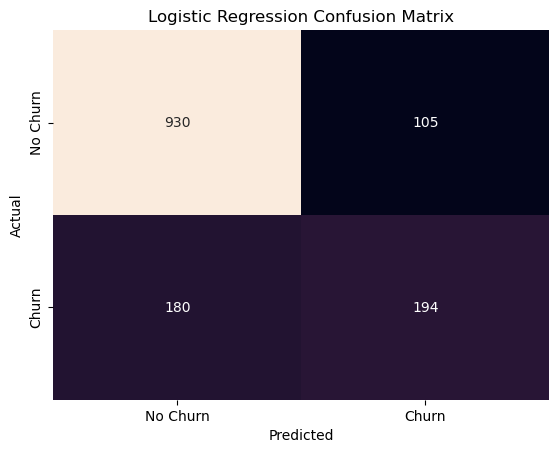

In [93]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [94]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [95]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [96]:
cat_model = CatBoostClassifier(
    verbose=False,
    random_state=42
)

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_test)

print(classification_report(y_test, cat_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [97]:
balanced_log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

balanced_log_model.fit(X_train, y_train)

balanced_pred = balanced_log_model.predict(X_test)

print(classification_report(y_test, balanced_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.75      1409



In [98]:
confusion_matrix(y_test, balanced_pred)

array([[738, 297],
       [ 80, 294]])

### Model Sonuçlarının Karşılaştırılması

Feature engineering sonrasında Logistic Regression, Random Forest, Gradient Boosting, CatBoost ve sınıf dengesizliğini dikkate alan Balanced Logistic Regression modelleri karşılaştırılmıştır.

Logistic Regression yaklaşık %80 accuracy, %52 churn recall ve %58 churn F1-score elde etmiştir. Random Forest modelinde accuracy yaklaşık %78, churn recall %49 ve churn F1-score %54 olarak bulunmuştur. Gradient Boosting yaklaşık %80 accuracy, %52 recall ve %58 F1-score elde ederken, CatBoost yaklaşık %80 accuracy, %54 recall ve %59 F1-score ile benzer bir performans göstermiştir.

Balanced Logistic Regression modelinde genel accuracy yaklaşık %73'e düşmesine rağmen churn sınıfındaki recall değeri %79'a yükselmiş ve F1-score %61 olarak elde edilmiştir. Confusion matrix sonucunda bu model 374 churn müşterisinin 294'ünü doğru tespit etmiş, 80 churn müşterisini ise kaçırmıştır. Bununla birlikte 297 churn olmayan müşteri yanlışlıkla churn olarak sınıflandırılmıştır.

Feature engineering öncesi ve sonrası sonuçlar karşılaştırıldığında model performanslarında büyük bir artış gözlenmemiştir. Logistic Regression'ın churn recall değeri %56'dan %52'ye ve F1-score değeri %60'tan %58'e düşerken, Random Forest sonuçları büyük ölçüde benzer kalmıştır. Gradient Boosting modelinde churn recall ve F1-score değerlerinde yaklaşık bir puanlık artış görülmüş, CatBoost'un temel performans değerleri ise değişmemiştir. Balanced Logistic Regression modelinde churn recall %78'den %79'a yükselirken genel accuracy %74'ten %73'e düşmüş ve F1-score %61 seviyesinde kalmıştır.

Bu sonuçlar, oluşturulan yeni değişkenlerin churn davranışını yorumlama açısından anlamlı bilgiler sağlamasına rağmen mevcut değişkenlerin taşıdığı bilgiyi büyük ölçüde yeniden temsil ettiğini ve tahmin performansına sınırlı katkı sağladığını göstermektedir. Genel doğruluk önceliklendirildiğinde standart modeller daha dengeli sonuç verirken, churn müşterilerinin mümkün olduğunca fazla tespit edilmesinin öncelikli olduğu bir senaryoda Balanced Logistic Regression daha uygun bir seçenek olarak değerlendirilebilir.

## 14. General Evaluation

Bu çalışmada Telco Customer Churn veri seti üzerinde veri inceleme, veri temizleme, keşifsel veri analizi, feature engineering, encoding, standardization ve farklı makine öğrenmesi modellerinin karşılaştırılması adımları uygulanmıştır.

EDA sonucunda özellikle `Contract`, `PaymentMethod`, `InternetService`, `OnlineSecurity`, `TechSupport`, `SeniorCitizen` ve `tenure` değişkenlerinde churn oranları açısından dikkat çekici farklılıklar gözlenmiştir. Bu bulgular doğrultusunda müşteri davranışını farklı açılardan temsil edebilmek amacıyla yeni etkileşim ve türetilmiş değişkenler oluşturulmuştur.

Feature engineering sonrasında model performanslarında belirgin bir genel artış elde edilmemiştir. Bu durum, oluşturulan yeni değişkenlerin önemli ölçüde mevcut değişkenlerde bulunan bilgiyi yeniden temsil ettiğini düşündürmektedir. Bununla birlikte feature engineering süreci, churn davranışının hangi müşteri özellikleri ve hizmet kombinasyonlarıyla ilişkili olduğunu daha açık biçimde ortaya koymuştur.

Model sonuçları birlikte değerlendirildiğinde, standart Logistic Regression, Gradient Boosting ve CatBoost modellerinin yaklaşık %80 accuracy ile benzer genel performans gösterdiği görülmüştür. Bununla birlikte bu modellerin churn sınıfındaki recall değerleri yaklaşık %52–54 aralığında kalmıştır. Random Forest modeli yaklaşık %78 accuracy, %49 churn recall ve %54 F1-score ile diğer standart modellerin biraz gerisinde kalmıştır. Balanced Logistic Regression ise genel accuracy değerini yaklaşık %73'e düşürmesine rağmen churn recall değerini %79'a yükseltmiş ve %61 F1-score elde etmiştir. Bu sonuçlar, genel sınıflandırma başarısı ile churn müşterilerini mümkün olduğunca yüksek oranda tespit etme hedefi arasında belirgin bir performans dengesi bulunduğunu göstermektedir.

Sonuç olarak kullanılacak modelin seçimi iş hedeflerine bağlıdır. Genel sınıflandırma doğruluğu önceliklendirildiğinde standart modeller tercih edilebilirken, churn riski taşıyan müşterilerin mümkün olduğunca yüksek oranda tespit edilmesinin daha önemli olduğu bir müşteri kaybı yönetimi senaryosunda yüksek recall sağlayan Balanced Logistic Regression daha uygun bir seçenek olarak değerlendirilebilir.